In [2]:
import tensorflow as tf
from tensorflow.keras import models ,layers
import matplotlib.pyplot as plt

In [3]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 40

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

class_names = dataset.class_names

train_size = 0.8
len(dataset) * train_size

train_ds = dataset.take(516)
len(train_ds)

temp_test_ds = dataset.skip(516)
len(temp_test_ds)

val_size = 0.1
len(dataset) * val_size

val_ds = temp_test_ds.take(64)
len(val_ds)

test_ds = temp_test_ds.skip(64)
len(test_ds)

def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shufflesize=10000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shufflesize, seed=12)  # Fixed the variable name here
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
   
    train_ds = ds.take(train_size)
    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size + val_size)  # Adjusted to skip both train and validation data
    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0 / 255)
])

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

n_classes = 15
# Define the image size and number of channels
IMAGE_SIZE = 256
CHANNELS = 3

# Define the rescaling factor
rescale_factor = 1.0 / 255.0

# Define the model
model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),  # Input layer with specified shape
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(n_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Train the model
history = model.fit(
    train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
)

# Evaluate the model
score = model.evaluate(test_ds)


Found 20638 files belonging to 15 classes.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 12, 12, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 4, 4, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 2, 2, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 15)                  │             975 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 184,527 (720.81 KB)

 Trainable params: 184,527 (720.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
516/516 ━━━━━━━━━━━━━━━━━━━━ 1757s 3s/step - accuracy: 0.3552 - loss: 2.4108 - val_accuracy: 0.7056 - val_loss: 0.9259
Epoch 2/40
516/516 ━━━━━━━━━━━━━━━━━━━━ 1581s 3s/step - accuracy: 0.7369 - loss: 0.7935 - val_accuracy: 0.7671 - val_loss: 0.7147
Epoch 3/40
516/516 ━━━━━━━━━━━━━━━━━━━━ 1713s 3s/step - accuracy: 0.8035 - loss: 0.5839 - val_accuracy: 0.8604 - val_loss: 0.4145
Epoch 4/40
516/516 ━━━━━━━━━━━━━━━━━━━━ 1337s 3s/step - accuracy: 0.8563 - loss: 0.4245 - val_accuracy: 0.8843 - val_loss: 0.3416
Epoch 5/40
516/516 ━━━━━━━━━━━━━━━━━━━━ 1382s 3s/step - accuracy: 0.8827 - loss: 0.3456 - val_accuracy: 0.8809 - val_loss: 0.3505
Epoch 6/40
516/516 ━━━━━━━━━━━━━━━━━━━━ 1198s 2s/step - accuracy: 0.9033 - loss: 0.2829 - val_accuracy: 0.8906 - val_loss: 0.3299
Epoch 7/40
516/516 ━━━━━━━━━━━━━━━━━━━━ 1090s 2s/step - accuracy: 0.9144 - loss: 0.2427 - val_accuracy: 0.9165 - val_loss: 0.2637
Epoch 8/40
516/516 ━━━━━━━━━━━━━━━━━━━━ 1055s 2s/step - accuracy: 0.9212 - loss: 0.2308 - 

In [4]:
history

In [5]:
history.params

{'verbose': 1, 'epochs': 40, 'steps': 516}

In [6]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [7]:
acc = history.history['accuracy']
val_acc = history.history['accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

In [8]:
len(acc)

40

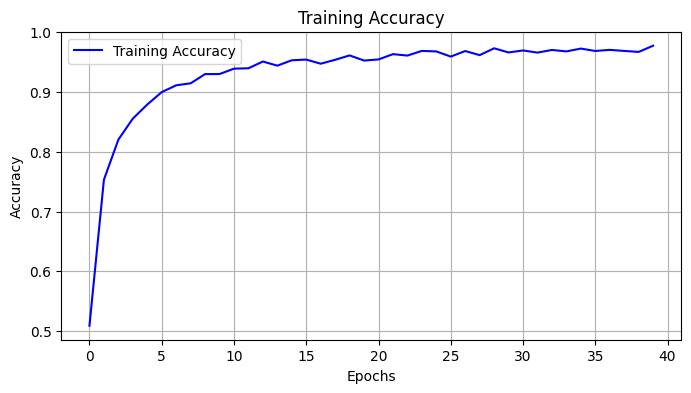

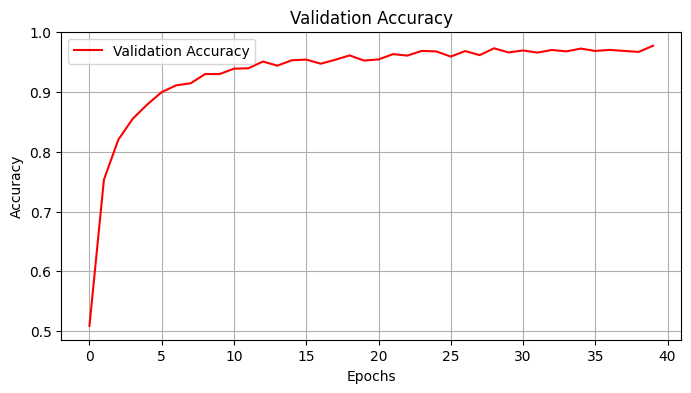

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(EPOCHS), acc, label='Training Accuracy', color='blue')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


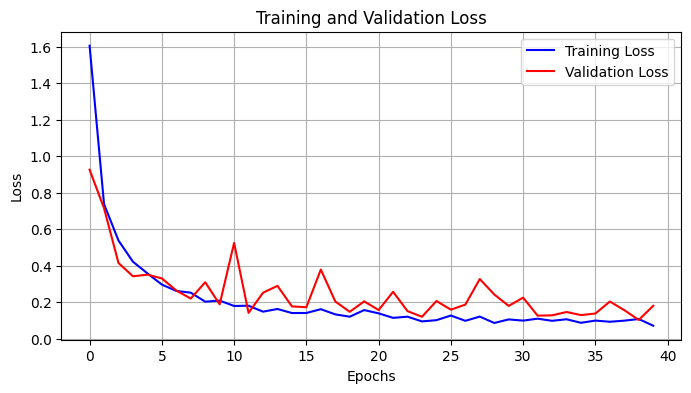

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

# Plot training loss
plt.plot(range(EPOCHS), loss, label='Training Loss', color='blue')

# Plot validation loss
plt.plot(range(EPOCHS), val_loss, label='Validation Loss', color='red')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


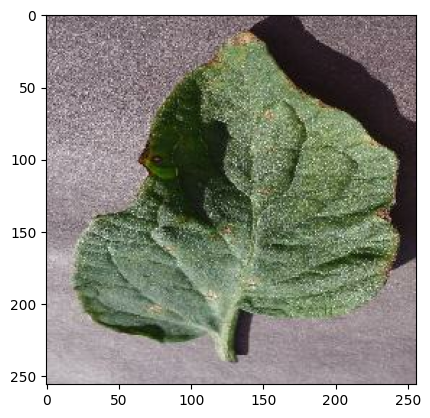

Actual label: Tomato__Target_Spot
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted probabilities: [1.7452953e-07 4.2517889e-11 4.2178453e-12 2.3849415e-11 4.7031552e-13
 7.6958059e-08 1.3967436e-05 1.0625347e-07 4.7693813e-09 2.3179207e-05
 4.6357567e-08 9.9996138e-01 1.9930698e-11 9.5604948e-13 1.0525345e-06]


In [13]:
import numpy as np
import matplotlib.pyplot as plt

image, label = next(iter(test_ds))

plt.imshow(image[0].numpy().astype('uint8'))
plt.show()

print("Actual label:", class_names[label[0].numpy()])

prediction = model.predict(image)

predicted_probabilities = prediction[0]

print("Predicted probabilities:", predicted_probabilities)


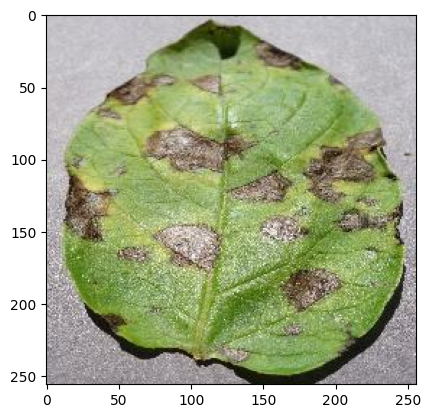

Actual label: Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 808ms/step
Predicted label: Potato___Early_blight


In [14]:
import numpy as np

for images_batch, labels_batch in test_ds.take(1):
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    plt.imshow(first_image)
    plt.show()
    
    print("Actual label:", class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    
    print("Predicted label:", class_names[np.argmax(batch_prediction[0])])


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Collect all predicted labels for the test set
predicted_labels = []
true_labels = []

for images_batch, labels_batch in test_ds:
    predictions = model.predict(images_batch)
    predicted_labels.extend(np.argmax(predictions, axis=1))
    true_labels.extend(labels_batch.numpy())

# Calculate F1 score
f1 = f1_score(true_labels, predicted_labels, average='weighted')
print("F1 score:", f1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 663ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 777ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 814ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 867ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 791ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 823ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 766ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 928ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 815ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 813ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 789ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 767ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 871ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 846ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 776ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 776ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 738ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 883ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 772ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [16]:
import numpy as np

# Initialize variables to count TP, FP, TN, FN
TP = 0
FP = 0
TN = 0
FN = 0

# Iterate over the test dataset to make predictions
for images_batch, labels_batch in test_ds:
    predictions_batch = model.predict(images_batch)
    predicted_labels_batch = np.argmax(predictions_batch, axis=1)
    
    # Update TP, FP, TN, FN counts
    for predicted_label, true_label in zip(predicted_labels_batch, labels_batch):
        if predicted_label == true_label:
            if predicted_label == 1:  # Positive class
                TP += 1
            else:  # Negative class
                TN += 1
        else:
            if predicted_label == 1:  # Positive class
                FP += 1
            else:  # Negative class
                FN += 1

# Calculate metrics
accuracy = (TP + TN) / (TP + FN + TN + FP)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)
sensitivity = recall
specificity = TN / (FP + TN)
false_positive_rate = 1 - specificity

# Print the calculated metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall (Sensitivity):", recall)
print("F1 Score:", f1_score)
print("Specificity:", specificity)
print("False Positive Rate:", false_positive_rate)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 833ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 769ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 778ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 873ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 911ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 914ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 831ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 722ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 832ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 787ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 723ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 771ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 802ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 769ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 897ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 818ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 661ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 835ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 834ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 887ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 791ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 789ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


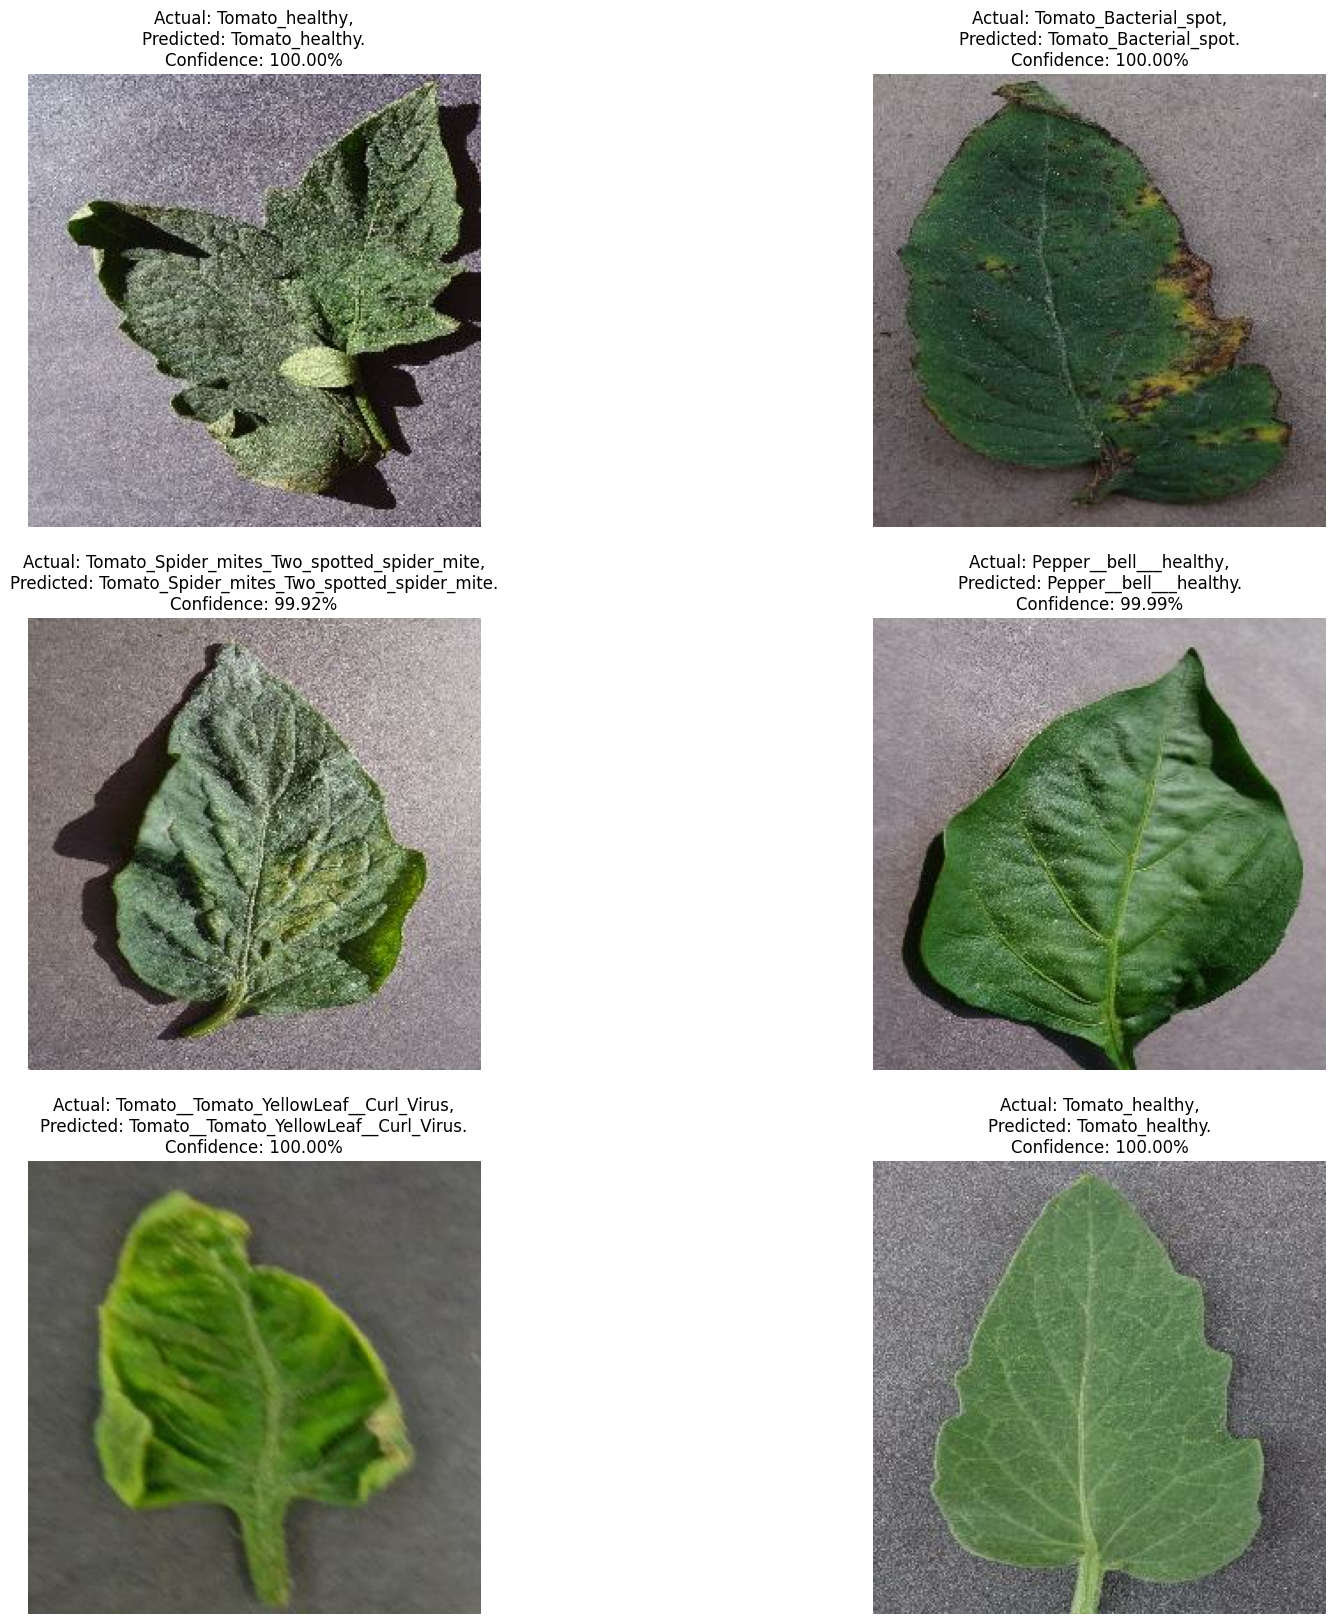

In [17]:
plt.figure(figsize=(20,20))
for images, labels in test_ds.take(1):
    for i in range(6):
        ax = plt.subplot(3, 2, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        predictions = model.predict(np.expand_dims(images[i], axis=0))
        predicted_class = class_names[np.argmax(predictions)]
        confidence = np.max(predictions) * 100
        actual_class = class_names[labels[i]]
        plt.title(f"Actual: {actual_class},\nPredicted: {predicted_class}.\nConfidence: {confidence:.2f}%")
        plt.axis("off")
    plt.show()


In [29]:
import os

# Directory path
directory = r"C:\Users\Abi Karimireddy\Downloads\deep learning\Training\final"

# Create directory if it doesn't exist
if not os.path.exists(directory):
    os.makedirs(directory)

# Now save your model
model_version = 1
model.save(f"{directory}{model_version}.keras")


In [30]:
import os

# Directory containing the model files
directory = r"C:\Users\Abi Karimireddy\Downloads\deep learning\Training\final"

# Get a list of all files in the directory
files = os.listdir(directory)

# Extract the numeric part of each filename
file_numbers = [int(i.split('.')[0]) for i in files if i.split('.')[0].isdigit()]

# Find the maximum version number and increment by 1
max_version = max(file_numbers) + 1 if file_numbers else 1

# Save the model with the incremented version number
model.save(f"{directory}/{max_version}.keras")
